In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
import tensorflow as tf
from tensorflow.keras import layers
from tqdm import tqdm
import cv2

In [2]:
from keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = np.array([cv2.resize(i, (32,32)) for i in x_train])
x_test = np.array([cv2.resize(i, (32,32)) for i in x_test])

x_train = (x_train / 255.0).astype('float32')
x_test = (x_test / 255.0).astype('float32')

x_train = x_train.reshape(x_train.shape[0], 32, 32, 1)
x_test = x_test.reshape(x_test.shape[0], 32, 32, 1)

In [24]:
def forward_noise(x, t, time_bar):
    noise = np.random.normal(size=x.shape)    
    t_bar = time_bar[t]    
    t_bar = t_bar.reshape((-1, 1, 1, 1))
    img_t = x * (1 - t_bar) + noise * t_bar
    
    t_1_bar = time_bar[t + 1]
    t_1_bar = t_1_bar.reshape((-1, 1, 1, 1))    
    img_t_1 = x * (1 - t_1_bar) + noise * t_1_bar
    return img_t, img_t_1

def show_examples(x):
    plt.figure(figsize=(10, 10))
    for i in range(len(x)):
        plt.subplot(1, len(x), i+1)       
        plt.imshow(x[i])
        plt.axis('off')

In [4]:
def block(x_img, x_ts):
    x_parameter = layers.Conv2D(128, kernel_size=3, padding='same', activation = 'relu')(x_img)

    time_parameter = layers.Dense(128, activation = 'relu')(x_ts)
    time_parameter = layers.Reshape((1, 1, 128))(time_parameter)
    x_parameter = x_parameter * time_parameter
    
    # -----
    x_out = layers.Conv2D(128, kernel_size=3, padding='same')(x_img)
    x_out = x_out + x_parameter
    x_out = layers.Activation('relu')(x_out)    
    return x_out

def make_model():
    x = x_input = layers.Input(shape=(32, 32, 1), name='x_input')
    
    x_ts = x_ts_input = layers.Input(shape=(1,), name='x_ts_input')
    x_ts = layers.Dense(192, activation = 'relu')(x_ts)
    
    # ----- left ( down ) -----
    x = x32 = block(x, x_ts)
    x = layers.Conv2D(32, 3, strides=2, padding='same', activation = 'relu')(x)
    
    x = x16 = block(x, x_ts)
    x = layers.Conv2D(64, 3, strides=2, padding='same', activation = 'relu')(x)
    
    x = x8 = block(x, x_ts)
    x = layers.Conv2D(128, 3, strides=2, padding='same', activation = 'relu')(x)
    
    x = x4 = block(x, x_ts)
    
    # ----- MLP -----
    x = layers.Flatten()(x)
    x = layers.Concatenate()([x, x_ts])
    x = layers.Dense(128, activation = 'relu')(x)

    x = layers.Dense(4 * 4 * 32, activation = 'relu')(x)
    x = layers.Reshape((4, 4, 32))(x)
    
    # ----- right ( up ) -----
    x = layers.Concatenate()([x, x4])
    x = block(x, x_ts)
    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation = 'relu')(x)
    
    x = layers.Concatenate()([x, x8])
    x = block(x, x_ts)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation = 'relu')(x)
    
    x = layers.Concatenate()([x, x16])
    x = block(x, x_ts)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation = 'relu')(x)
    
    x = layers.Concatenate()([x, x32])
    x = block(x, x_ts)
    
    # ----- output -----
    x = layers.Conv2D(1, kernel_size=1, padding='same')(x)
    model = tf.keras.models.Model([x_input, x_ts_input], x)
    return model

In [17]:
def train_model(model, x_train, time_bar, no_of_time_steps, batch_size, epochs):
    for epoch in range(epochs):
        no_of_iterations = x_train.shape[0]//batch_size
        for _ in tqdm(range(no_of_iterations)):   
            idx = np.random.randint(0, x_train.shape[0], size=batch_size) # random training images
            x_train_batch = x_train[idx] # random training images
            t_train_batch = np.random.randint(0, no_of_time_steps, size=batch_size) # random time generation
            
            x_t, x_t_1 = forward_noise(x_train_batch, t_train_batch, time_bar) # images at time t and t+1 (forward noise)            
            model.train_on_batch([x_t, t_train_batch], x_t_1) # model training    
    
        # Plot Testing Results#
        # Model prediction on a randomly selected test image#
        predictions = []        
        idx = np.random.randint(0, x_test.shape[0], size=1)
        x_test_batch = x_test[idx]
        for t in range(no_of_time_steps):
            x_t, _ = forward_noise(x_test_batch, t, time_bar)        
            x = model.predict([x_t, np.full((1),  t)], verbose=0)                
            predictions.append(x[0])
        
        # Model prediction on randomly generated Gaussian noise#
        x = np.random.normal(size = (1,32,32,1))          
        for t in range(no_of_time_steps):    
            x = model.predict([x, np.full((1),  t)], verbose=0)   
            predictions.append(x[0])              

        counter = -1
        fig, ax = plt.subplots(2,no_of_time_steps)
        for i in range(2):
            for j in range(no_of_time_steps):
                counter += 1 
                ax[i,j].imshow(predictions[counter])
                ax[i,j].axis('off')        
        plt.draw()
        plt.pause(0.00001) 

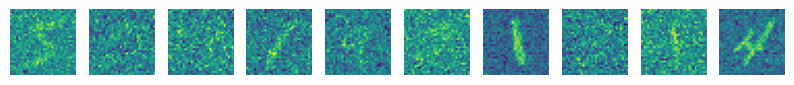

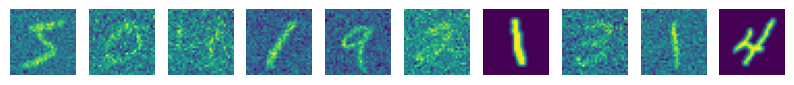

In [26]:
no_of_time_steps = 5  
time_bar = 1 - np.linspace(0, 1, no_of_time_steps + 1) 

t = np.random.randint(0, no_of_time_steps, size=10)
x_t, x_t_1 = forward_noise(x_train[:10], t, time_bar)
show_examples(x_t)
show_examples(x_t_1)

In [27]:
model = make_model()
model.summary()
model.compile(optimizer='adam', loss='mae')

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
x_ts_input (InputLayer)         [(None, 1)]          0                                            
__________________________________________________________________________________________________
dense_11 (Dense)                (None, 192)          384         x_ts_input[0][0]                 
__________________________________________________________________________________________________
x_input (InputLayer)            [(None, 32, 32, 1)]  0                                            
__________________________________________________________________________________________________
dense_12 (Dense)                (None, 128)          24704       dense_11[0][0]                   
____________________________________________________________________________________________

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:39<00:00, 11.84it/s]


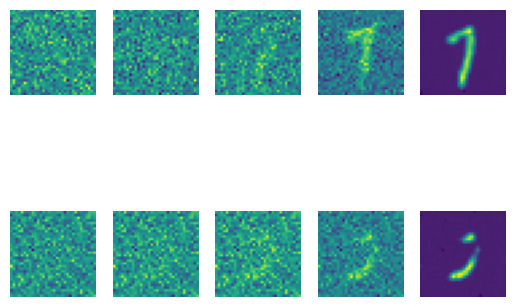

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:37<00:00, 12.33it/s]


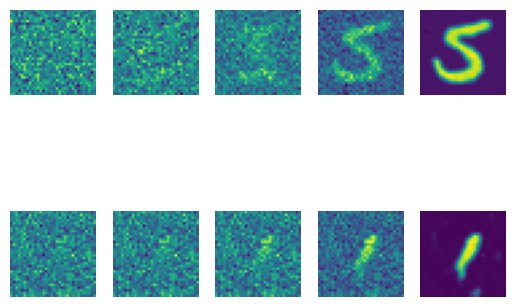

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.84it/s]


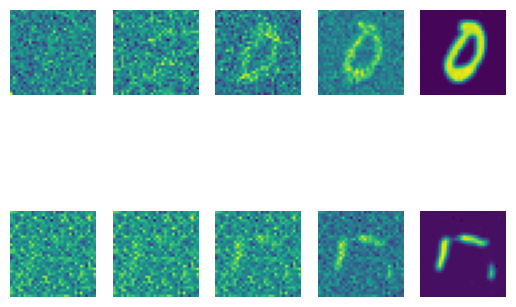

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.79it/s]


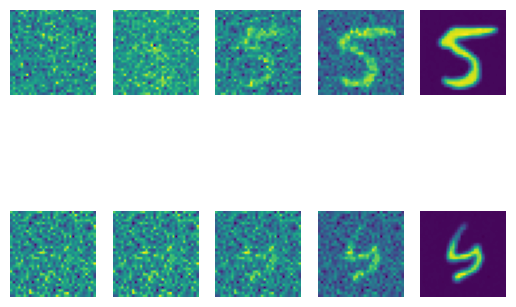

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:37<00:00, 12.47it/s]


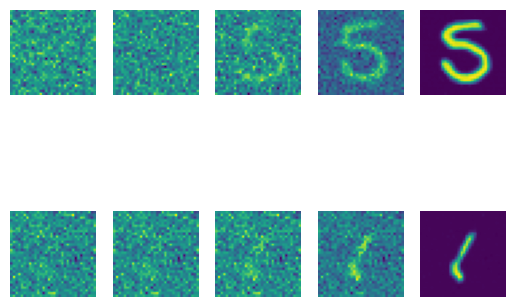

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:37<00:00, 12.49it/s]


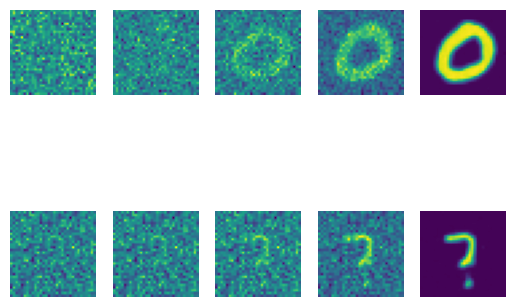

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:39<00:00, 11.87it/s]


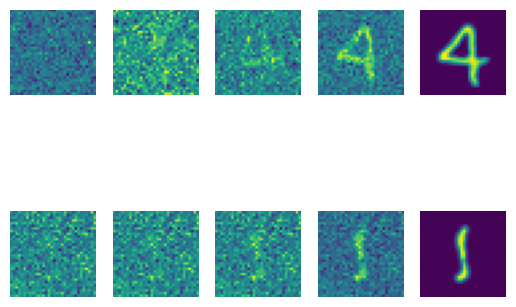

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.83it/s]


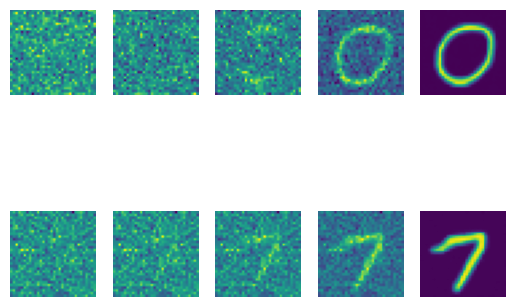

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.85it/s]


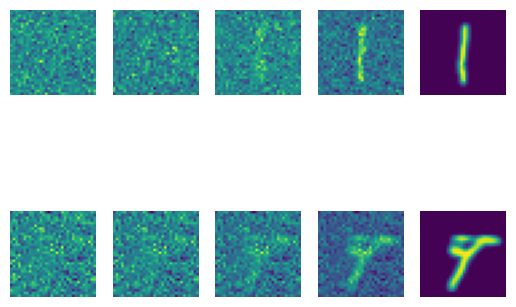

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.88it/s]


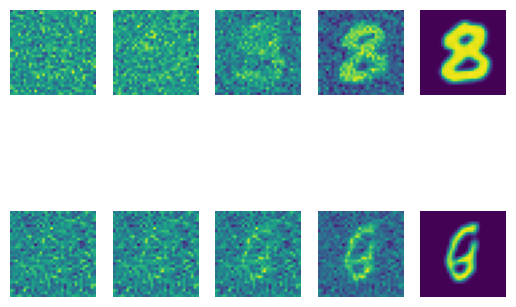

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:37<00:00, 12.57it/s]


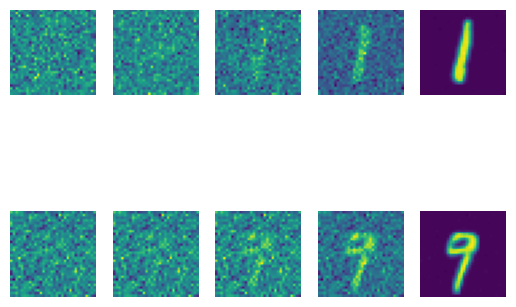

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:37<00:00, 12.48it/s]


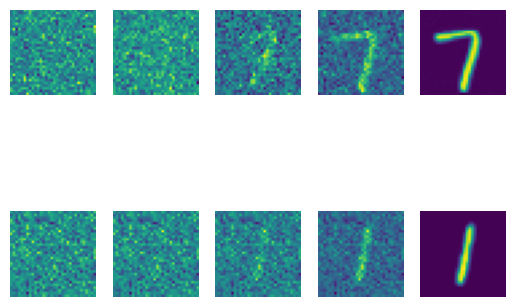

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:37<00:00, 12.64it/s]


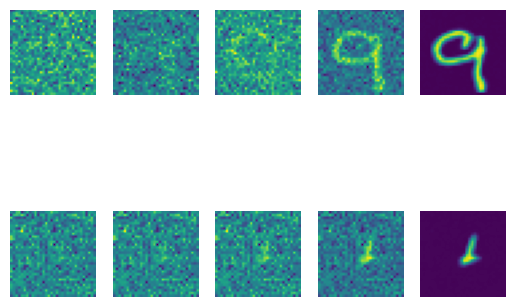

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:37<00:00, 12.49it/s]


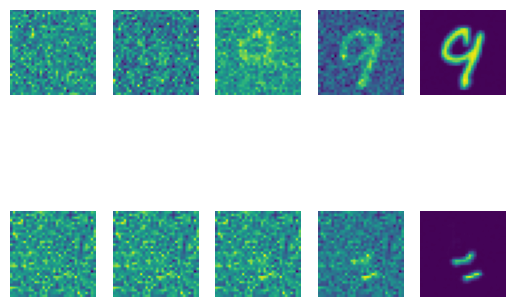

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:37<00:00, 12.53it/s]


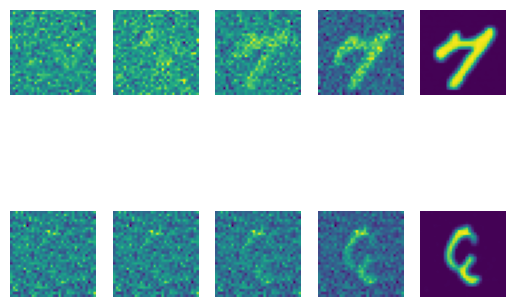

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:37<00:00, 12.53it/s]


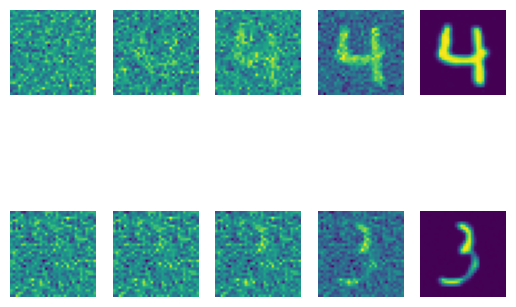

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:37<00:00, 12.60it/s]


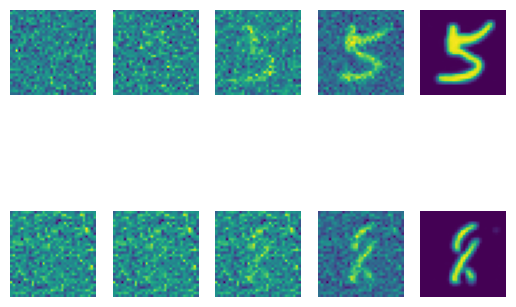

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.82it/s]


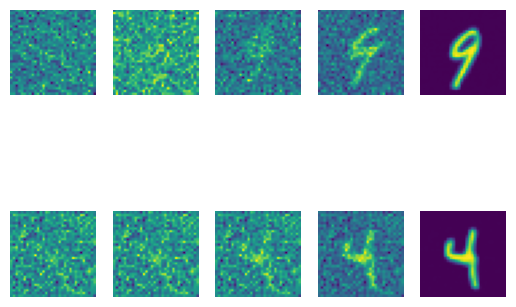

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.83it/s]


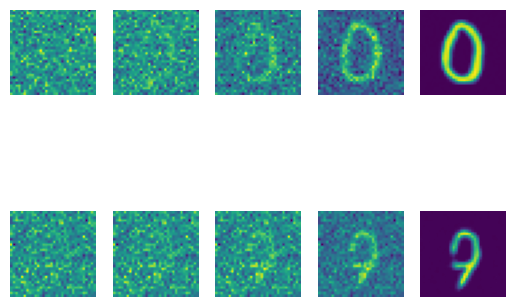

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.81it/s]


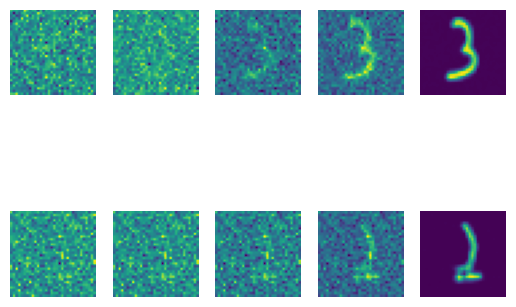

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.81it/s]


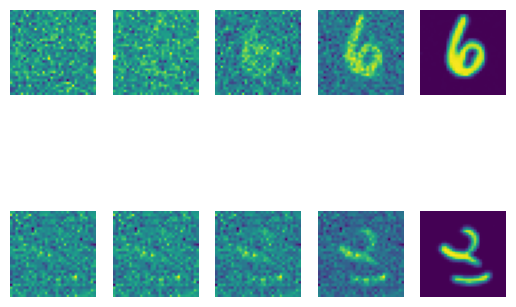

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.86it/s]


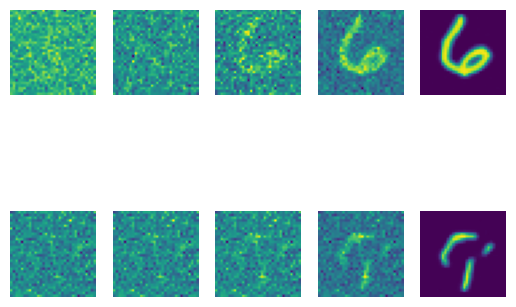

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.85it/s]


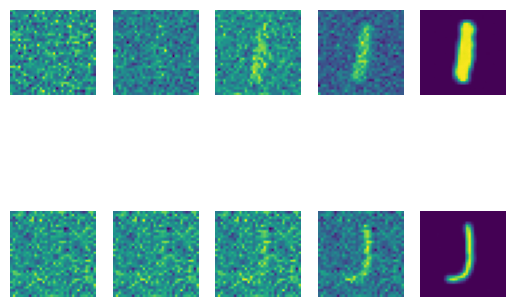

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.77it/s]


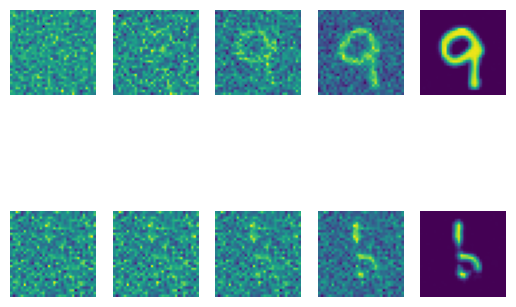

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.84it/s]


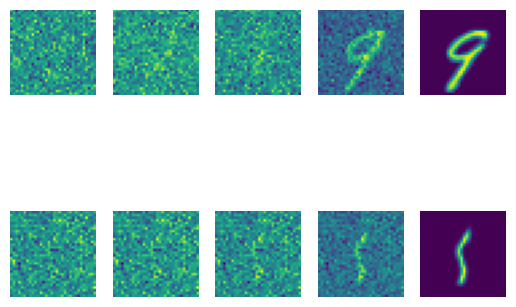

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.91it/s]


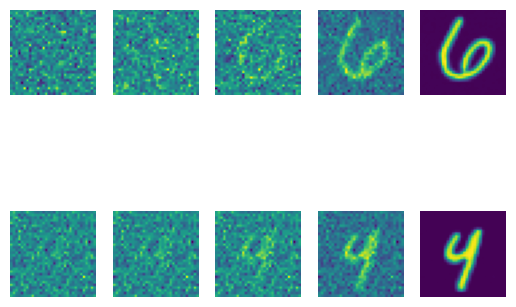

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.97it/s]


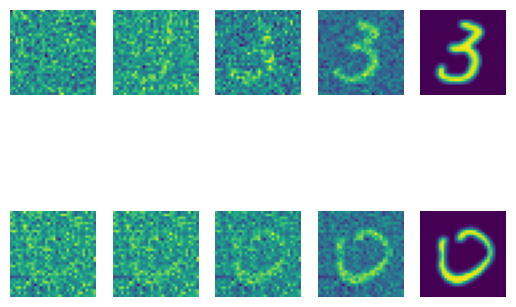

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:37<00:00, 12.44it/s]


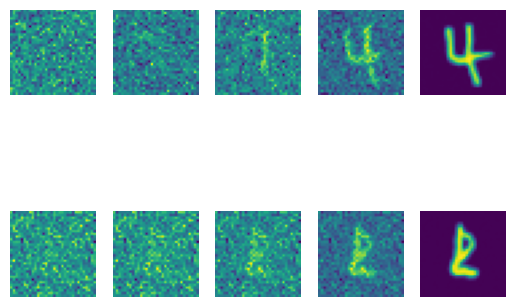

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.82it/s]


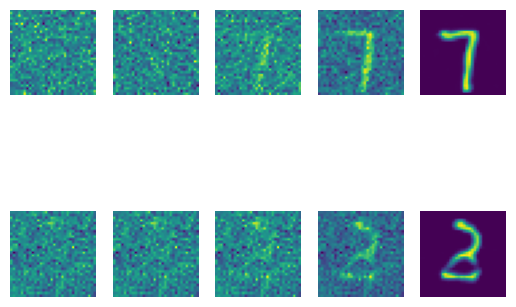

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.84it/s]


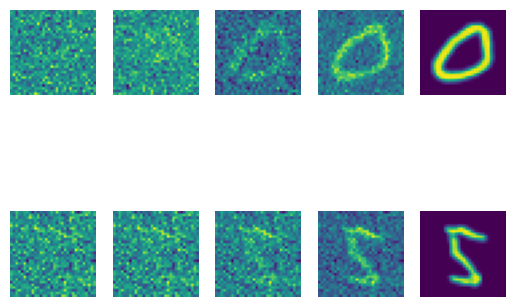

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.83it/s]


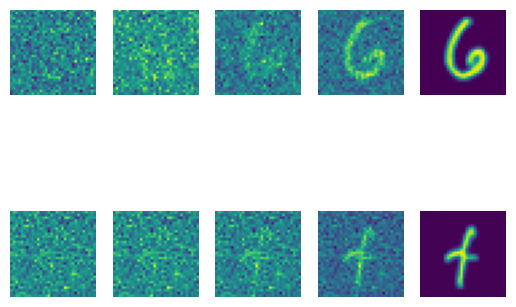

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.73it/s]


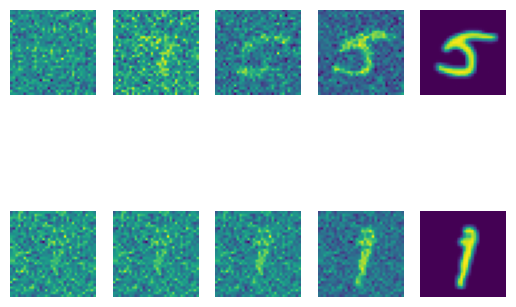

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:38<00:00, 12.24it/s]


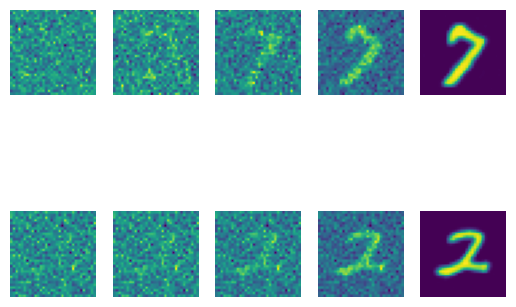

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.79it/s]


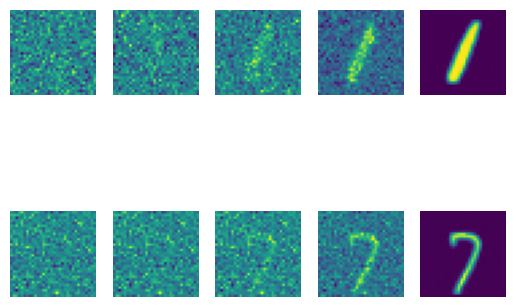

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:37<00:00, 12.53it/s]


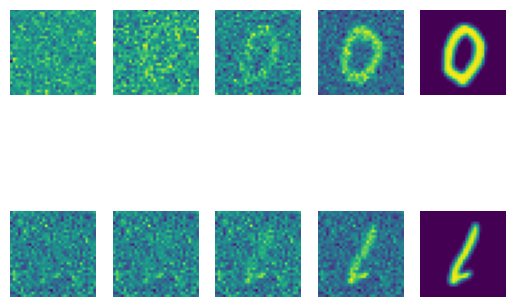

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.79it/s]


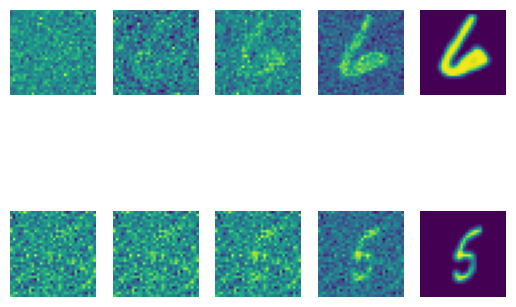

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:37<00:00, 12.62it/s]


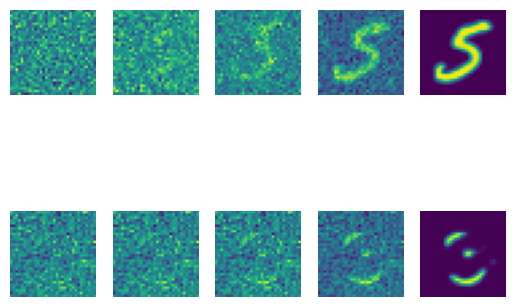

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.84it/s]


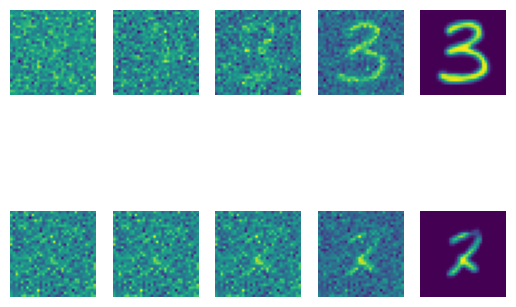

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.71it/s]


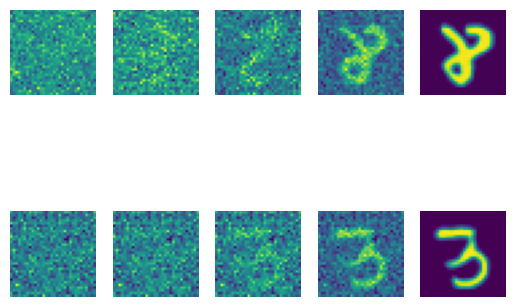

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.84it/s]


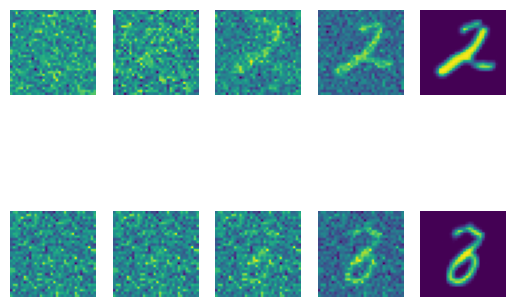

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.82it/s]


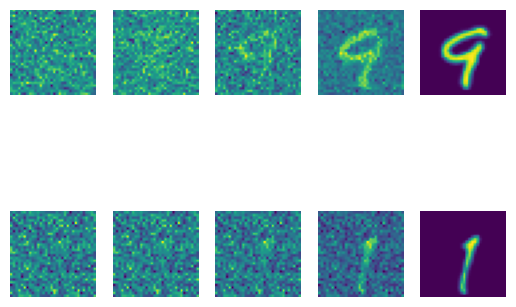

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.80it/s]


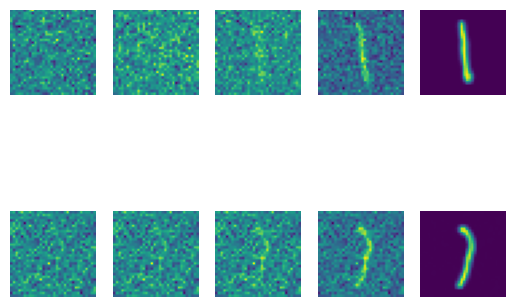

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.83it/s]


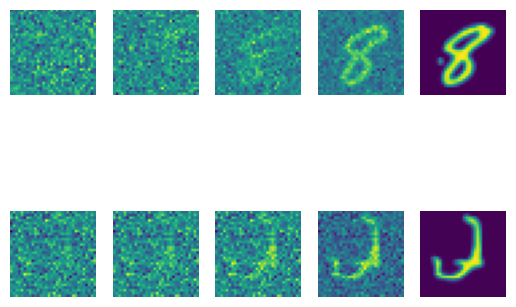

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.65it/s]


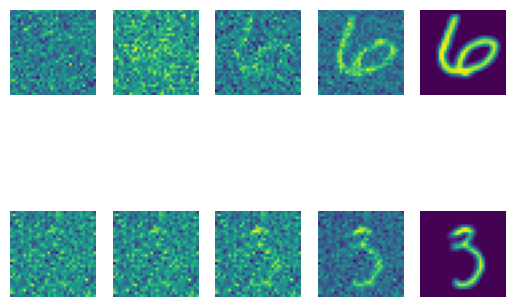

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.74it/s]


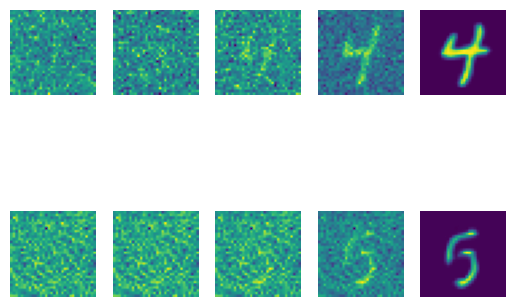

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.92it/s]


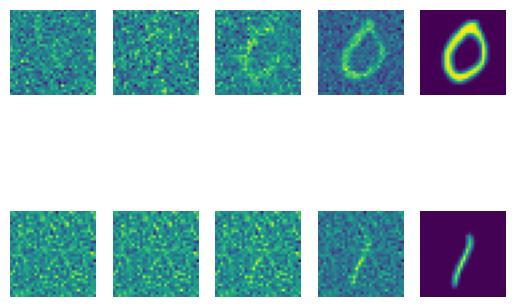

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:37<00:00, 12.63it/s]


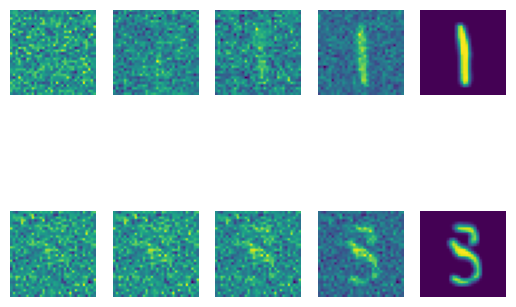

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.89it/s]


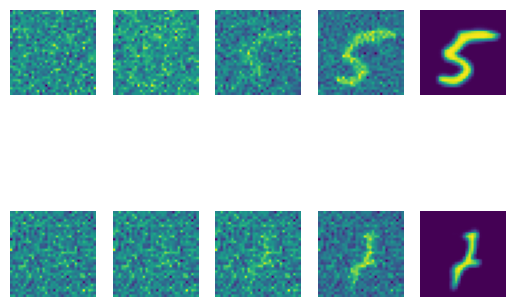

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.90it/s]


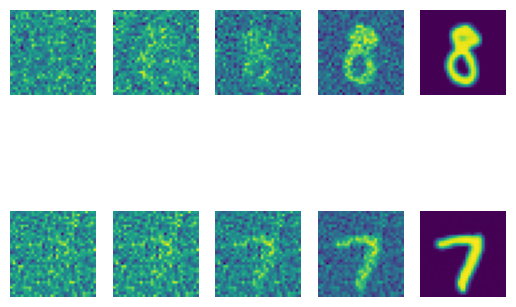

100%|████████████████████████████████████████████████████████████████████████████████| 468/468 [00:36<00:00, 12.90it/s]


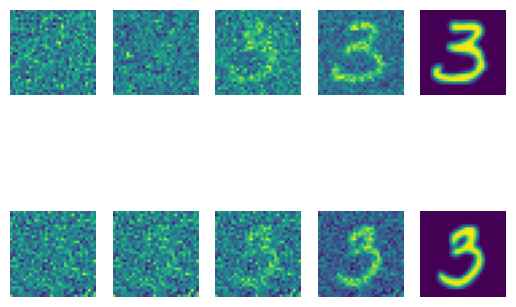

In [28]:
batch_size = 128
epochs = 50
train_model(model, x_train, time_bar, no_of_time_steps, batch_size, epochs)

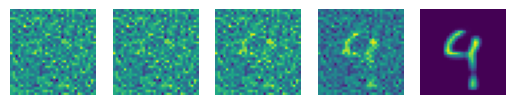

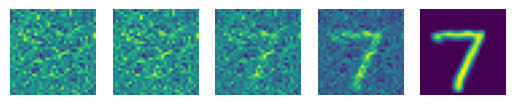

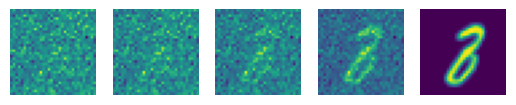

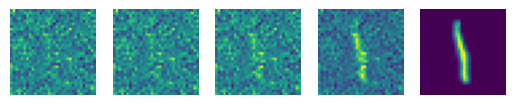

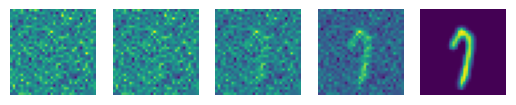

In [41]:
############### Sample Generated Images ###############
for i in range(5):
    x = np.random.normal(size = (1,32,32,1))
    predictions = []
    for t in range(no_of_time_steps):    
        x = model.predict([x, np.full((1),  t)], verbose=0)           
        predictions.append(x[0])   
    
    fig, ax = plt.subplots(1, no_of_time_steps)
    for i in range(no_of_time_steps):
        ax[i].imshow(predictions[i])
        ax[i].axis('off')                